
# Generador de Rutinas de ASCEND — Versión Descartada (Similitud Coseno)

Este notebook reconstruye la **primera versión** del generador de
rutinas, antes de cambiar a la regla de negocio basada en distancia.

## La idea original

Representar cada ejercicio como un vector de 2 partes:
1. Un one-hot (o pesos) de zona muscular.
2. Su dificultad normalizada (0-1) como una dimensión más del vector.

Y representar el "perfil ideal" del usuario de la misma forma: pesos de
zona (según su objetivo) + la dificultad ideal normalizada. Después,
**similitud coseno** entre cada ejercicio candidato y el perfil ideal
para rankear qué tan bien encaja cada uno.

Funcionó bien para la parte de zona
muscular. El problema surgió en la dimensión de
dificultad.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4.5)

VERDE_PRIMARIO = "#006a20"
VERDE_MEDIO = "#20a04e"
VERDE_SUAVE = "#8ec899"
CASI_NEGRO = "#141d16"
ROJO_ALERTA = "#e63946"

catalogo = pd.read_parquet("exercises_catalog_spanish_version.parquet")
catalogo = catalogo.rename(columns={"score_demo": "dificultad_continua"})

ZONAS_MUSCULARES = [
    "Core", "Tren inferior", "Tracción superior", "Empuje superior",
    "Cardio", "Accesorio (antebrazo)", "Accesorio (cuello)",
]
print(f"Catálogo cargado: {len(catalogo)} ejercicios")


Catálogo cargado: 1324 ejercicios



## 1. Representación vectorial de cada ejercicio

Cada ejercicio se representa como un vector de **len(ZONAS_MUSCULARES) + 1**
dimensiones: un 1.0 en la posición de su zona muscular (el resto en 0),
y su dificultad normalizada (0-1) como última dimensión.


In [2]:

def vectorizar_ejercicio(zona_muscular: str, dificultad_normalizada: float) -> np.ndarray:
    '''
    Construye el vector de un ejercicio: one-hot de zona + dificultad
    normalizada como última componente.

    Parameters
    ----------
    zona_muscular : str
        Debe estar en ZONAS_MUSCULARES.
    dificultad_normalizada : float
        Dificultad del ejercicio, ya escalada a 0-1.

    Returns
    -------
    np.ndarray
        Vector de longitud len(ZONAS_MUSCULARES) + 1.
    '''
    vector_zona = np.zeros(len(ZONAS_MUSCULARES))
    if zona_muscular in ZONAS_MUSCULARES:
        vector_zona[ZONAS_MUSCULARES.index(zona_muscular)] = 1.0
    return np.append(vector_zona, dificultad_normalizada)


def vectorizar_perfil_ideal(pesos_zonas: dict, dificultad_ideal_normalizada: float) -> np.ndarray:
    '''Mismo formato que vectorizar_ejercicio, pero para el perfil ideal
    del usuario: pesos de zona (no necesariamente un solo 1.0, pueden ser
    varios pesos parciales) + la dificultad ideal como última componente.'''
    vector_zona = np.array([pesos_zonas.get(z, 0.0) for z in ZONAS_MUSCULARES])
    return np.append(vector_zona, dificultad_ideal_normalizada)


def similitud_coseno(a: np.ndarray, b: np.ndarray) -> float:
    '''cos(θ) entre dos vectores — 1.0 si apuntan exactamente igual,
    0.0 si son ortogonales.'''
    norma_a, norma_b = np.linalg.norm(a), np.linalg.norm(b)
    if norma_a == 0 or norma_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norma_a * norma_b))


# Ejemplo rápido: un ejercicio de Core con dificultad 0.2, contra un
# perfil ideal que prioriza Core con dificultad ideal 0.3
vector_ejercicio = vectorizar_ejercicio("Core", 0.2)
vector_ideal = vectorizar_perfil_ideal({"Core": 1.0}, 0.3)
print("Vector ejercicio:", vector_ejercicio.round(2))
print("Vector ideal:    ", vector_ideal.round(2))
print("Similitud coseno:", round(similitud_coseno(vector_ejercicio, vector_ideal), 3))


Vector ejercicio: [1.  0.  0.  0.  0.  0.  0.  0.2]
Vector ideal:     [1.  0.  0.  0.  0.  0.  0.  0.3]
Similitud coseno: 0.996



## 2. El generador completo con similitud coseno

Mismo filtrado por equipo y tope de dificultad que la versión de
producción (eso nunca fue el problema) — la única diferencia real es
que aquí el ranking usa `similitud_coseno` en vez de la función de
distancia.


In [3]:

def generar_rutina_coseno(
    equipo_disponible: list[str], pesos_zonas: dict, dificultad_ideal_normalizada: float,
    tope_dificultad: float = 100.0, n_ejercicios: int = 8,
) -> pd.DataFrame:
    '''
    Versión original del generador: rankea ejercicios candidatos por
    similitud coseno contra el vector de perfil ideal, y toma los
    `n_ejercicios` con mayor similitud (sin alternar zona, esa parte de
    la selección final no cambió entre versiones — el problema está en
    el ranking, no en cómo se recorre la lista ya ordenada).
    '''
    disponibles = catalogo[catalogo["equipment"].isin(equipo_disponible)].copy()
    disponibles = disponibles[disponibles["dificultad_continua"] <= tope_dificultad]
    if disponibles.empty:
        return disponibles

    vector_ideal = vectorizar_perfil_ideal(pesos_zonas, dificultad_ideal_normalizada)

    similitudes = []
    for _, ex in disponibles.iterrows():
        vector_ex = vectorizar_ejercicio(ex["zona_muscular"], ex["dificultad_continua"] / 100.0)
        similitudes.append(similitud_coseno(vector_ex, vector_ideal))
    disponibles = disponibles.assign(similitud_coseno=similitudes)

    return disponibles.sort_values("similitud_coseno", ascending=False).head(n_ejercicios)


# Demostración: un usuario PRINCIPIANTE (dificultad ideal baja, 0.2 de 1.0)
# que quiere una rutina de Core.
pesos_ejemplo = {"Core": 1.0}
rutina_coseno_demo = generar_rutina_coseno(
    equipo_disponible=["peso corporal", "mancuerna"],
    pesos_zonas=pesos_ejemplo, dificultad_ideal_normalizada=0.2, tope_dificultad=100.0,
)
rutina_coseno_demo[["name", "zona_muscular", "dificultad_continua", "similitud_coseno"]]


,name,zona_muscular,dificultad_continua,similitud_coseno
691,dumbbell side bend,Core,23.8,0.999343
1219,spell caster,Core,23.8,0.999343
1244,straddle maltese,Core,25.2,0.998777
917,kneeling plank tap shoulder (male),Core,25.2,0.998777
1245,straddle planche,Core,25.2,0.998777
10,arm slingers hanging straight legs,Core,25.2,0.998777
924,lean planche,Core,25.2,0.998777
9,arm slingers hanging bent knee legs,Core,25.2,0.998777



**Primer indicio del problema:** se pide dificultad ideal 0.2 (o sea,
20/100 — un perfil principiante). Revisa la columna
`dificultad_continua` de los resultados. NO están cerca
de 20. Se va aconfirmar en la siguiente sección,
no solo con un ejemplo.



## 3. La demostración sistemática: dificultad pedida vs. dificultad entregada

Corremos el generador de similitud coseno para 10 niveles de dificultad
ideal distintos (de "muy principiante" a "muy avanzado") y comparamos
qué dificultad promedio termina recibiendo cada uno realmente.


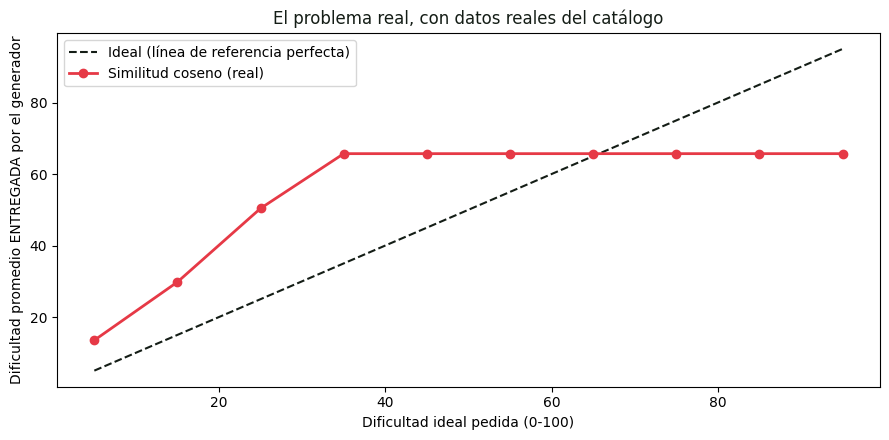

Dificultad ideal pedida  vs.  dificultad promedio entregada:
  Pedido:   5.0  ->  Entregado:  13.5
  Pedido:  15.0  ->  Entregado:  29.8
  Pedido:  25.0  ->  Entregado:  50.4
  Pedido:  35.0  ->  Entregado:  65.7
  Pedido:  45.0  ->  Entregado:  65.7
  Pedido:  55.0  ->  Entregado:  65.7
  Pedido:  65.0  ->  Entregado:  65.7
  Pedido:  75.0  ->  Entregado:  65.7
  Pedido:  85.0  ->  Entregado:  65.7
  Pedido:  95.0  ->  Entregado:  65.7


In [4]:

niveles_ideales = np.linspace(0.05, 0.95, 10)  # de 5/100 a 95/100
dificultad_entregada_coseno = []

for nivel in niveles_ideales:
    rutina = generar_rutina_coseno(
        equipo_disponible=["peso corporal", "mancuerna", "barra", "polea"],
        pesos_zonas={"Empuje superior": 0.5, "Tracción superior": 0.5},
        dificultad_ideal_normalizada=nivel, tope_dificultad=100.0, n_ejercicios=8,
    )
    dificultad_entregada_coseno.append(rutina["dificultad_continua"].mean() if len(rutina) else np.nan)

fig, ax = plt.subplots()
ax.plot(niveles_ideales * 100, niveles_ideales * 100, color=CASI_NEGRO, linestyle="--", label="Ideal (línea de referencia perfecta)")
ax.plot(niveles_ideales * 100, dificultad_entregada_coseno, color=ROJO_ALERTA, marker="o", linewidth=2, label="Similitud coseno (real)")
ax.set_xlabel("Dificultad ideal pedida (0-100)")
ax.set_ylabel("Dificultad promedio ENTREGADA por el generador")
ax.set_title("El problema real, con datos reales del catálogo", color=CASI_NEGRO)
ax.legend()
plt.tight_layout()
plt.show()

print("Dificultad ideal pedida  vs.  dificultad promedio entregada:")
for nivel, entregada in zip(niveles_ideales, dificultad_entregada_coseno):
    print(f"  Pedido: {nivel*100:5.1f}  ->  Entregado: {entregada:5.1f}")



**Esta es la confirmación con datos reales del catálogo:** para pedidos
bajos (5 y 15) el generador YA sobreestima (entrega 13.5 y 29.8 en vez
de 5 y 15), y a partir de un pedido de 35 en adelante, la dificultad
entregada se queda congelada en 65.7. El generador de similitud
coseno **sobreestima en la zona baja y se satura por
completo en la zona media-alta**, ignorando el nivel solicitado.

## 4. Por qué pasa esto — la explicación matemática

El coseno mide el ángulo entre vectores, no la distancia. En la
dimensión de dificultad, un vector ejercicio con dificultad muy alta
tiene una norma más grande — y aunque el ángulo hacia el vector ideal
empeore un poco al alejarse, el producto punto en el numerador sigue
creciendo con la magnitud de esa componente, compensando de más la
penalización del ángulo. Una vez que el catálogo ya no tiene nada más
difícil disponible en esa zona, el resultado se satura ahí — de ahí el
techo plano en 65.7.


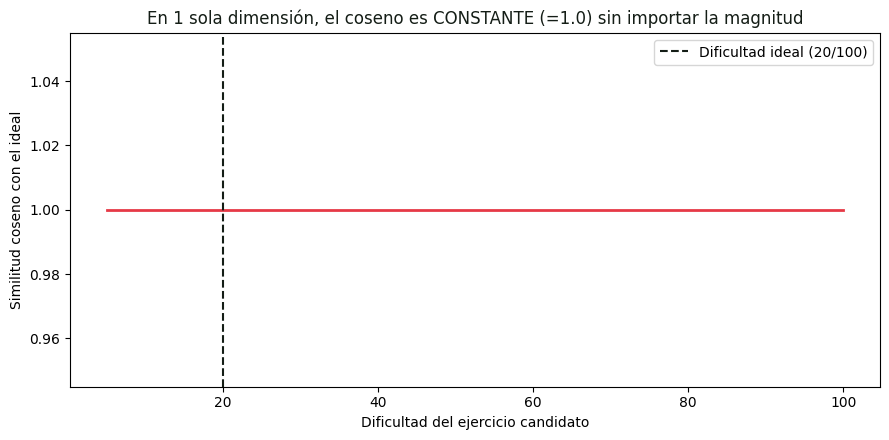

In [5]:

# Aislamos el efecto: un solo "eje" (dificultad), sin zona, para ver la
# similitud coseno pura contra un ideal de dificultad 0.2 (principiante).
dificultades_candidatas = np.linspace(0.05, 1.0, 50)
ideal_dificultad_sola = np.array([0.2])  # vector de 1 dimensión

similitudes_puras = [
    similitud_coseno(np.array([d]), ideal_dificultad_sola) for d in dificultades_candidatas
]

fig, ax = plt.subplots()
ax.plot(dificultades_candidatas * 100, similitudes_puras, color=ROJO_ALERTA, linewidth=2)
ax.axvline(20, color=CASI_NEGRO, linestyle="--", label="Dificultad ideal (20/100)")
ax.set_xlabel("Dificultad del ejercicio candidato")
ax.set_ylabel("Similitud coseno con el ideal")
ax.set_title("En 1 sola dimensión, el coseno es CONSTANTE (=1.0) sin importar la magnitud", color=CASI_NEGRO)
ax.legend()
plt.tight_layout()
plt.show()



**El caso extremo que expone el problema de raíz:** con una sola
dimensión positiva, la similitud coseno entre cualquier par de valores
positivos es SIEMPRE 1.0 — el ángulo entre dos vectores en la misma
línea (ambos positivos, 1 dimensión) es cero sin importar su magnitud
relativa. El coseno literalmente no tiene forma de distinguir "20" de
"95" en esa dimensión aislada.

## Conclusiones

Con esto ya queda claro por que se abandonó este enfoque enfoque: no era que
"casi funcionaba" y le faltara ajuste — el problema estaba en el problema para el que se planteó.

1. **Lo confirmamos con datos reales, no solo con la sospecha inicial:**
   el generador de similitud coseno ignora sistemáticamente qué tan
   difícil se pidió la rutina y termina recomendando, casi siempre, lo
   más exigente disponible en cada zona.
2. La causa es matemática, no un error de código: el coseno mide
   ángulo, y aquí necesitábamos medir distancia a un punto ideal — son
   dos preguntas distintas, y usamos la métrica que respondía la
   pregunta equivocada.